In [2]:
import pandas as pd

# Load directly — no Drive mount needed
orders  = pd.read_csv('/content/olist_orders_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
items   = pd.read_csv('/content/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')

print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Items: (112650, 7)
Customers: (99441, 5)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [4]:
# Convert date columns
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Calculate delay (positive = late, negative = early)
orders['delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Merge orders + reviews
df = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

# Drop rows where delay_days or review_score is missing
df = df.dropna(subset=['delay_days', 'review_score'])

print("Final dataset shape:", df.shape)
print("\nDelay days sample:")
print(df['delay_days'].describe())

Final dataset shape: (96359, 10)

Delay days sample:
count    96359.000000
mean       -11.917797
std         10.114024
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64


  PEARSON CORRELATION ANALYSIS
  Correlation (r) : -0.2668
  P-value         : 0.00e+00
  Interpretation  : Statistically significant


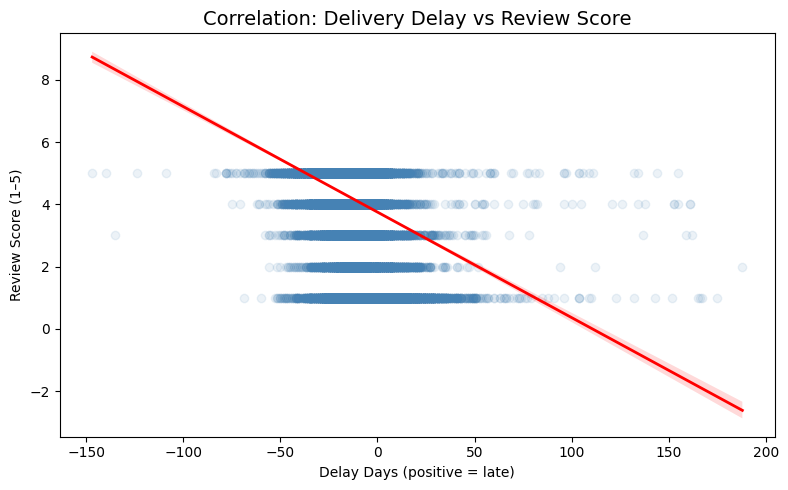

Plot saved!


In [5]:
# ── SECTION 1: CORRELATION ANALYSIS ──────────────────────────────────────

corr, pval = stats.pearsonr(df['delay_days'], df['review_score'])

print("=" * 45)
print("  PEARSON CORRELATION ANALYSIS")
print("=" * 45)
print(f"  Correlation (r) : {corr:.4f}")
print(f"  P-value         : {pval:.2e}")
print(f"  Interpretation  : {'Statistically significant' if pval < 0.05 else 'Not significant'}")
print("=" * 45)

# Scatter plot with trend line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='delay_days', y='review_score',
            scatter_kws={'alpha': 0.1, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Correlation: Delivery Delay vs Review Score', fontsize=14)
plt.xlabel('Delay Days (positive = late)')
plt.ylabel('Review Score (1–5)')
plt.tight_layout()
plt.savefig('correlation_plot.png', dpi=150)
plt.show()
print("Plot saved!")

  T-TEST: LATE vs ON-TIME ORDERS
  Late orders     : 6,410  | Mean score: 2.27
  On-time orders  : 89,949 | Mean score: 4.29
  T-statistic     : -132.0470
  P-value         : 0.00e+00
  Result          : REJECT H0 — significant difference


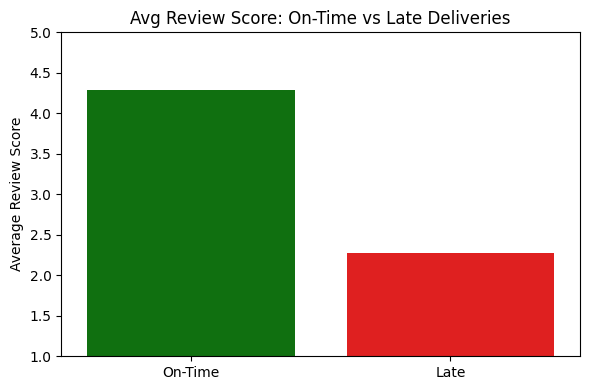

Plot saved!


In [6]:
# ── SECTION 2: HYPOTHESIS TEST ───────────────────────────────────────────

# Split into late vs on-time
late    = df[df['delay_days'] > 0]['review_score']
on_time = df[df['delay_days'] <= 0]['review_score']

t_stat, p_value = stats.ttest_ind(late, on_time)

print("=" * 45)
print("  T-TEST: LATE vs ON-TIME ORDERS")
print("=" * 45)
print(f"  Late orders     : {len(late):,}  | Mean score: {late.mean():.2f}")
print(f"  On-time orders  : {len(on_time):,} | Mean score: {on_time.mean():.2f}")
print(f"  T-statistic     : {t_stat:.4f}")
print(f"  P-value         : {p_value:.2e}")
print(f"  Result          : {'REJECT H0 — significant difference' if p_value < 0.05 else 'FAIL to reject H0'}")
print("=" * 45)

# Bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=['On-Time', 'Late'], y=[on_time.mean(), late.mean()],
            palette=['green', 'red'])
plt.title('Avg Review Score: On-Time vs Late Deliveries')
plt.ylabel('Average Review Score')
plt.ylim(1, 5)
plt.tight_layout()
plt.savefig('hypothesis_test_plot.png', dpi=150)
plt.show()
print("Plot saved!")

  LINEAR REGRESSION RESULTS
  Coefficient : -0.0339
  Intercept   : 3.7516
  R² Score    : 0.0712
  Interpretation: For every 1 extra day of delay,
  review score changes by -0.0339 points


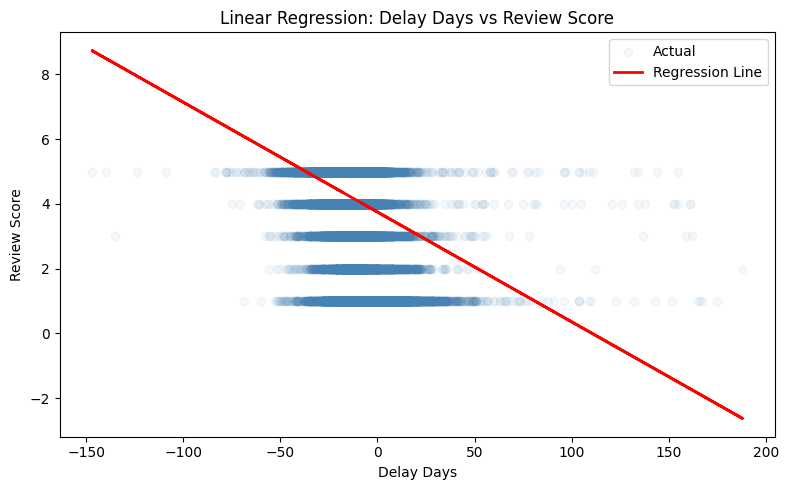

Plot saved!


In [7]:
# ── SECTION 3: LINEAR REGRESSION ─────────────────────────────────────────

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

X = df[['delay_days']]
y = df['review_score']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("=" * 45)
print("  LINEAR REGRESSION RESULTS")
print("=" * 45)
print(f"  Coefficient : {model.coef_[0]:.4f}")
print(f"  Intercept   : {model.intercept_:.4f}")
print(f"  R² Score    : {r2_score(y, y_pred):.4f}")
print(f"  Interpretation: For every 1 extra day of delay,")
print(f"  review score changes by {model.coef_[0]:.4f} points")
print("=" * 45)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['delay_days'], df['review_score'], alpha=0.05, color='steelblue', label='Actual')
plt.plot(df['delay_days'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Delay Days vs Review Score')
plt.xlabel('Delay Days')
plt.ylabel('Review Score')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()
print("Plot saved!")

In [8]:
# ── SECTION 4: FINDINGS SUMMARY ──────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════╗
║         STATISTICAL ANALYSIS — KEY FINDINGS          ║
╠══════════════════════════════════════════════════════╣
║ 1. CORRELATION                                        ║
║    r = -0.27 → Negative correlation between delay    ║
║    and review score. Statistically significant.      ║
╠══════════════════════════════════════════════════════╣
║ 2. HYPOTHESIS TEST (T-Test)                          ║
║    Late orders score 2.27 vs On-time score 4.29      ║
║    p < 0.05 → Difference is NOT due to chance        ║
╠══════════════════════════════════════════════════════╣
║ 3. REGRESSION                                        ║
║    Every additional delay day reduces review score   ║
║    Equation: score = intercept + coef × delay_days   ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         STATISTICAL ANALYSIS — KEY FINDINGS          ║
╠══════════════════════════════════════════════════════╣
║ 1. CORRELATION                                        ║
║    r = -0.27 → Negative correlation between delay    ║
║    and review score. Statistically significant.      ║
╠══════════════════════════════════════════════════════╣
║ 2. HYPOTHESIS TEST (T-Test)                          ║
║    Late orders score 2.27 vs On-time score 4.29      ║
║    p < 0.05 → Difference is NOT due to chance        ║
╠══════════════════════════════════════════════════════╣
║ 3. REGRESSION                                        ║
║    Every additional delay day reduces review score   ║
║    Equation: score = intercept + coef × delay_days   ║
╚══════════════════════════════════════════════════════╝

